**Feature Importance** - Feature importance methods assign scores to each feature in a dataset, indicating how much each feature contributes to the model's ability to make accurate predictions. Shap values are one of them.

**Shap (Shapley Additive Explanations) values** - a method for explaining the output of any machine learning model. Game theoretic approach to assign importance values to each feature. Version shap==0.41.0 supports color map changes.


**y** - target numerical variable. ( e.g. Brennwert )


**x**  - numerical data without y


**random. seed(42)** -  a pop-culture reference! In Douglas Adams's popular 1979 science-fiction novel The Hitchhiker's Guide to the Galaxy, towards the end of the book, the supercomputer Deep Thought reveals that the answer to the great question of “life, the universe and everything” is 42.







In [ ]:
pip install matplotlib plotly scikit-learn mxnet-mkl==1.6.0 numpy==1.23.1 shap==0.41.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 36.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display
import math
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 191)
%matplotlib inline
from pandas import read_excel

import os
import scipy.ndimage
import scipy.stats
import plotly.express as px
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import datasets, ensemble, model_selection

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
import seaborn as sns
import numpy as np
np.bool = np.bool_
import shap

In [ ]:
print(shap.__version__)

0.49.1


In [ ]:
# Load the excel file
my_sheet = 'milch' # change it to your sheet name, you can find your sheet name at the bottom left of your excel file
file_name = 'Milch.xlsx' # change it to the name of your excel file
df = read_excel(file_name, sheet_name = my_sheet)
print(df)

                                               Name Herkunft        Farbstoff  \
0                          SUCOFIN Magermilchpulver       DE             Ohne   
1                            EDEKA Kaffeeweißer G&G       DE             Ohne   
2                   SALITER Magermilchpulver Allgau       DE             Ohne   
3                           MARESI Magermilchpulver       AT             Ohne   
4                         MILBONA LIDL Kaffeeweißer       NL    E160a Karotin   
5                            S-BUDGET Kaffeeweisser       NL    E160a Karotin   
6                              SUCOFIN Kaffeeweißer       DE    E160a Karotin   
7                     SPAR Kaffeeweißer Laktosefrei       NL    E160a Karotin   
8                  MIGROS Rapilait Magermilchpulver       CH             Ohne   
9                        COOP Prix Magermilchpulver       CH             Ohne   
10                   NESTLE Gloria Magermilchpulver       FR             Ohne   
11                          

In [ ]:
print (df.dtypes)

Name                          object
Herkunft                      object
Farbstoff                     object
Vegan                         object
Glutenfrei                    object
Pulver                        object
Brennwert                      int64
Kohlenhydraten               float64
Fett                         float64
Protein                      float64
Protein per Fett             float64
Zucker                       float64
Zucker per Kohlenhydraten    float64
Salz                         float64
Info                          object
dtype: object


In [ ]:
df.index.values

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.set_index("Name",drop=True,inplace=True)

In [ ]:
# Declare Categorical and Numerical Columns

In [ ]:
# Data
X = df.drop(['Brennwert'], axis=1)
#print(df_num)

# Target
y = df['Brennwert']
#print(y)

In [ ]:
# Data
categorical_columns = ["Herkunft","Farbstoff", "Vegan", "Glutenfrei","Pulver", "Info"]
numerical_columns = ["Kohlenhydraten","Fett","Protein", "Protein per Fett", "Zucker", "Zucker per Kohlenhydraten", "Salz"]

In [ ]:
# fit model
enc = OrdinalEncoder()
X[categorical_columns] = enc.fit_transform(X[categorical_columns] )
# Combine Numerical and categorical data
x = X[categorical_columns + numerical_columns]


In [ ]:
# Default test_size is 0.25, or 25 percent.
# 25 percent of samples are assigned to the test set, 75% is for training
#x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=0)

In [ ]:
# Create and train the RandomForestRegressor
regressor = ensemble.RandomForestRegressor()
regressor.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
# Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(regressor)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(x_train)

In [ ]:
# Assuming 'shap_values' and 'X_train' are already calculated
features = x_train.columns.tolist()

In [ ]:
# sort by Average Elevation descending
df = df.sort_values('Brennwert', ascending=False)

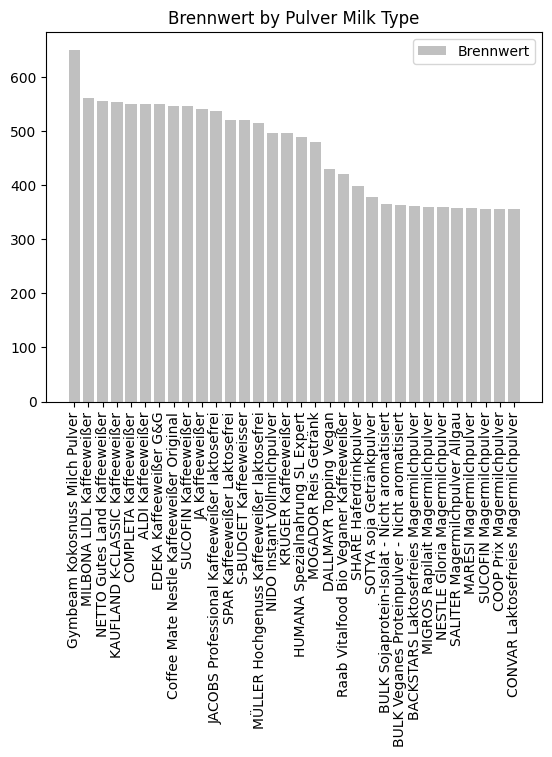

In [ ]:
# generate the basic plot
fig, ax = plt.subplots()
# Average Elevation (m above the sea level) bars for every Tea
ax.bar(df.index, df['Brennwert'], label='Brennwert',color='#C0C0C0')
ax.set_title('Brennwert by Pulver Milk Type')
ax.tick_params(axis='x', labelrotation=90)
ax.legend()

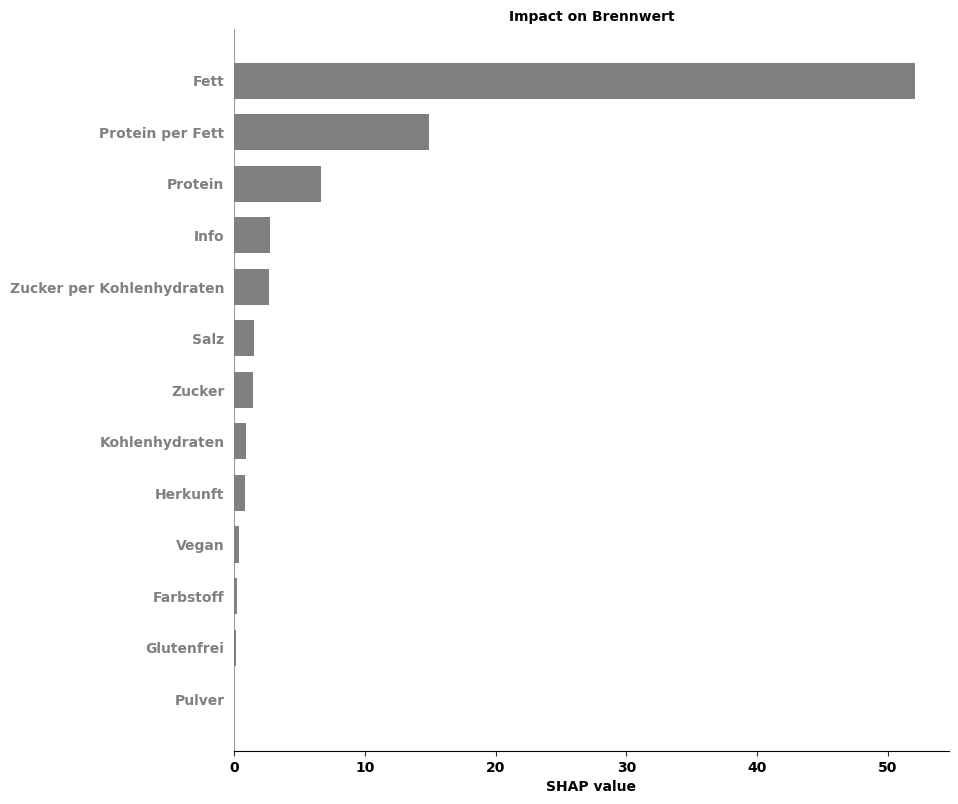

In [ ]:
shap.summary_plot(shap_values, x_train,show=False, feature_names=features, plot_size=(10,8), plot_type="bar", color="grey")
plt.title('Impact on Brennwert',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
plt.yticks(fontsize=10,color='grey',fontproperties="DejaVu Sans",weight='bold')
plt.xticks(fontsize=10,color='black',fontproperties="DejaVu Sans",weight='bold')
plt.xlabel('SHAP value',fontsize=10,fontproperties="DejaVu Sans",weight='bold')
plt.show()

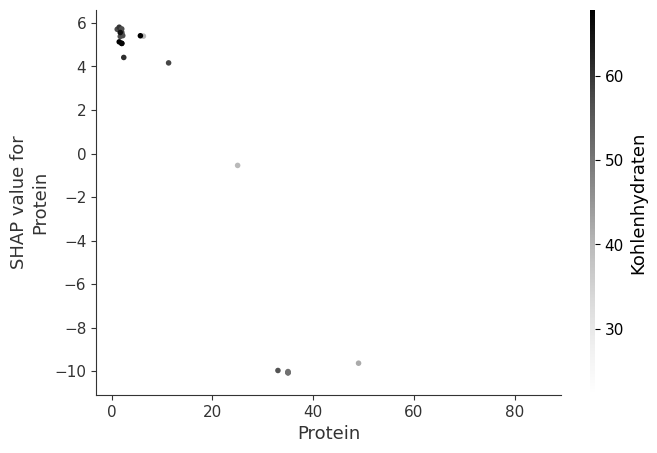

In [ ]:
# Assuming 'shap_values', 'X_train', and 'features' are available
feature_index = 8 # 12 Salz, 1 Farbstoff, 3 Glutenfrei, ...
shap.dependence_plot(feature_index, shap_values, x_train, feature_names=features, cmap="Greys")
plt.show()
#plt.show()

In [ ]:
# x_train and y_train rows count (e.g. 15) must be the same
print(x_train.shape)
print(y_train.shape)

(24, 13)
(24,)


In [ ]:
# print(x_train)

In [ ]:
# print(y_train)